In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df_scaled = pickle.load(open('data/df_scaled.pkl', 'rb'))
df_clean  = pickle.load(open('data/df_clean.pkl',  'rb'))
df_pca    = pickle.load(open('data/df_pca.pkl',    'rb'))

print('Data loaded. Shape:', df_scaled.shape)
print('Features:', list(df_clean.columns))


Data loaded. Shape: (2224, 9)
Features: ['Age', 'Income', 'TotalSpend', 'TotalPurchases', 'TotalChildren', 'Recency', 'Days_Customer', 'TotalAccepted', 'NumWebVisitsMonth']


Testing K values...
  K=2  Inertia=14220  Silhouette=0.2654
  K=3  Inertia=12686  Silhouette=0.1916
  K=4  Inertia=11627  Silhouette=0.1564
  K=5  Inertia=10587  Silhouette=0.1643
  K=6  Inertia=10015  Silhouette=0.1565
  K=7  Inertia=9565  Silhouette=0.1475
  K=8  Inertia=9150  Silhouette=0.1462
  K=9  Inertia=8747  Silhouette=0.1464
  K=10  Inertia=8446  Silhouette=0.1399


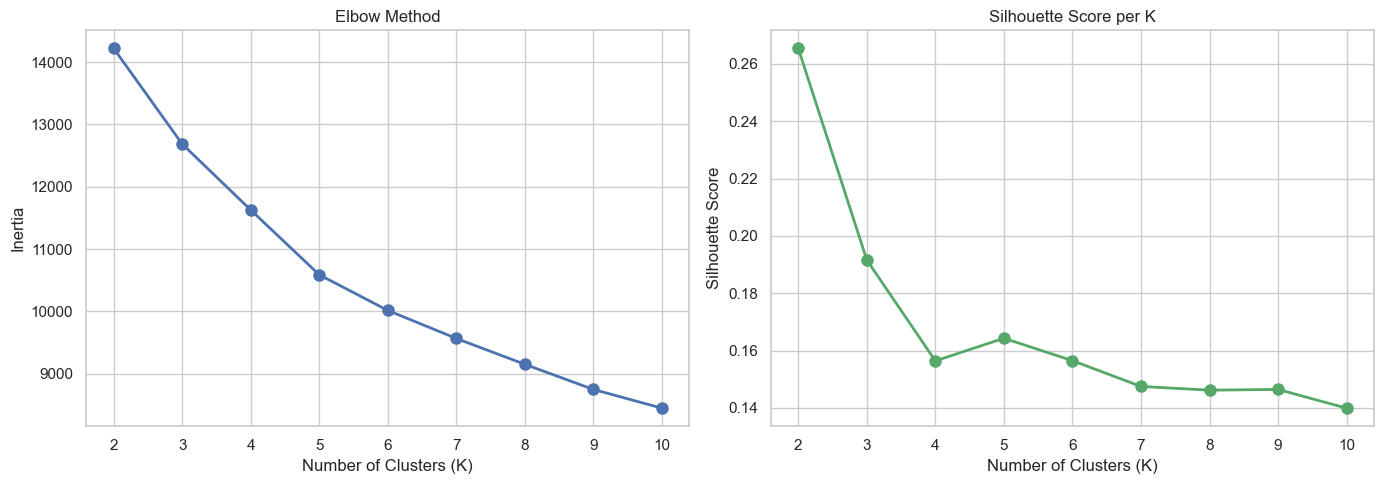


Best K = 2  (Silhouette = 0.2654)


In [2]:
inertia    = []
sil_scores = []
K_range    = range(2, 11)

print('Testing K values...')
for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(df_scaled, labels))
    print(f'  K={k}  Inertia={km.inertia_:.0f}  Silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('data/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f'\nBest K = {best_k}  (Silhouette = {max(sil_scores):.4f})')


In [3]:
K = best_k  # or manually set: K = 4

km_final  = KMeans(n_clusters=K, random_state=42, n_init=10)
km_labels = km_final.fit_predict(df_scaled)

df_result             = df_clean.copy()
df_result['Cluster']  = km_labels

print(f'K-Means trained with K={K}')
print('\nCluster sizes:')
print(df_result['Cluster'].value_counts().sort_index())


K-Means trained with K=2

Cluster sizes:
Cluster
0     969
1    1255
Name: count, dtype: int64


In [4]:
sil = silhouette_score(df_scaled, km_labels)
dbs = davies_bouldin_score(df_scaled, km_labels)

print('=== K-Means Evaluation Metrics ===')
print(f'Number of Clusters  : {K}')
print(f'Silhouette Score    : {sil:.4f}  (higher = better, max 1.0)')
print(f'Davies-Bouldin Score: {dbs:.4f}  (lower  = better, min 0.0)')
print(f'Inertia             : {km_final.inertia_:.2f}')

scores = {'algorithm': 'K-Means', 'n_clusters': K,
          'silhouette': round(sil, 4), 'davies_bouldin': round(dbs, 4),
          'inertia': round(km_final.inertia_, 2), 'noise': 0}
pickle.dump(scores,    open('data/kmeans_scores.pkl', 'wb'))
pickle.dump(km_labels, open('data/kmeans_labels.pkl', 'wb'))
print('\nSaved!')


=== K-Means Evaluation Metrics ===
Number of Clusters  : 2
Silhouette Score    : 0.2654  (higher = better, max 1.0)
Davies-Bouldin Score: 1.5090  (lower  = better, min 0.0)
Inertia             : 14220.47

Saved!


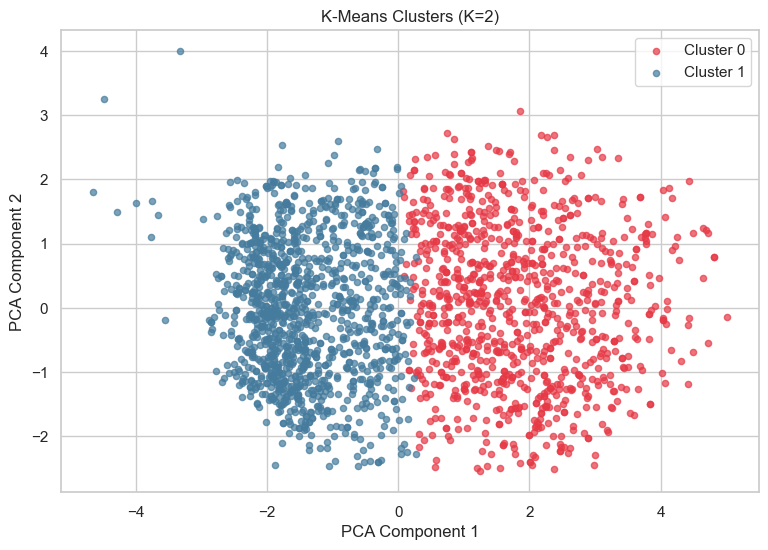

In [5]:
# PCA 2D cluster plot
colors = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653','#7B2D8B']

plt.figure(figsize=(9, 6))
for i in range(K):
    mask = km_labels == i
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1],
                s=20, color=colors[i], label=f'Cluster {i}', alpha=0.7)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'K-Means Clusters (K={K})')
plt.legend()
plt.savefig('data/kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()


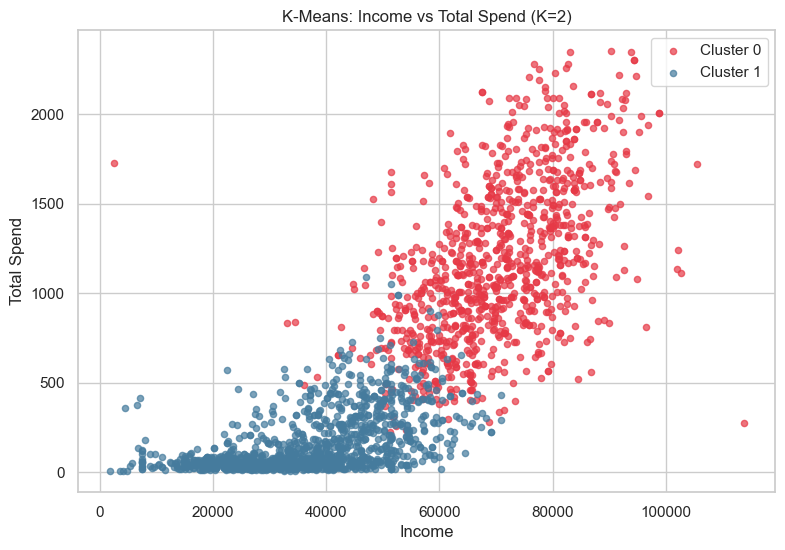

In [6]:
# Income vs TotalSpend coloured by cluster
plt.figure(figsize=(9, 6))
for i in range(K):
    mask = km_labels == i
    plt.scatter(df_clean.loc[mask, 'Income'],
                df_clean.loc[mask, 'TotalSpend'],
                s=20, color=colors[i], label=f'Cluster {i}', alpha=0.7)
plt.xlabel('Income')
plt.ylabel('Total Spend')
plt.title(f'K-Means: Income vs Total Spend (K={K})')
plt.legend()
plt.savefig('data/kmeans_income_spend.png', dpi=150, bbox_inches='tight')
plt.show()


=== Cluster Profiles (Mean Values) ===
           Age    Income  TotalSpend  TotalPurchases  TotalChildren  Recency  \
Cluster                                                                        
0        57.41  70276.67     1172.88           21.48           0.55    49.53   
1        53.37  37090.02      159.95            9.73           1.26    48.78   

         Days_Customer  TotalAccepted  NumWebVisitsMonth  
Cluster                                                   
0              3846.96           0.78               3.83  
1              3811.52           0.19               6.51  


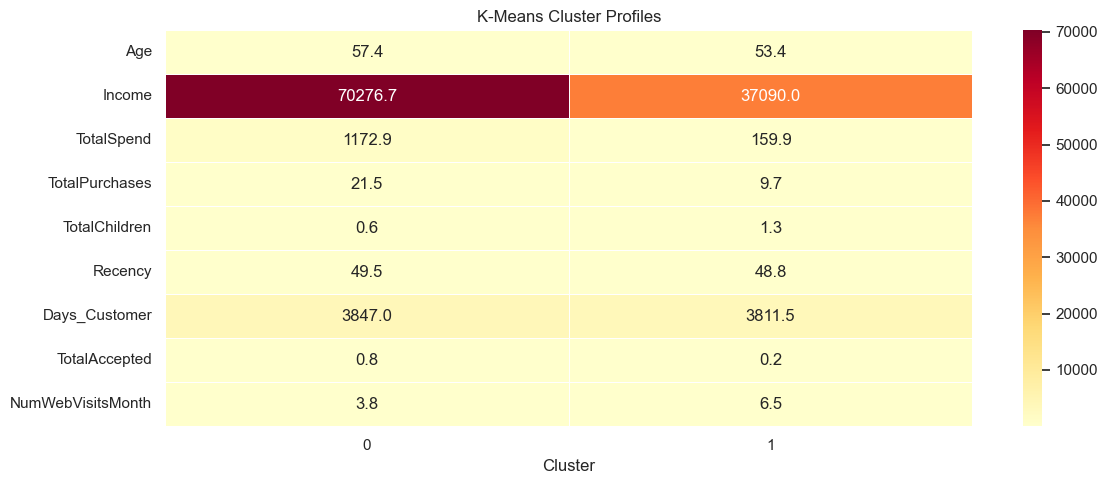

In [7]:
# Cluster profile heatmap
print('=== Cluster Profiles (Mean Values) ===')
profile = df_result.groupby('Cluster').mean().round(2)
print(profile)

plt.figure(figsize=(12, 5))
sns.heatmap(profile.T, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('K-Means Cluster Profiles')
plt.tight_layout()
plt.savefig('data/kmeans_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


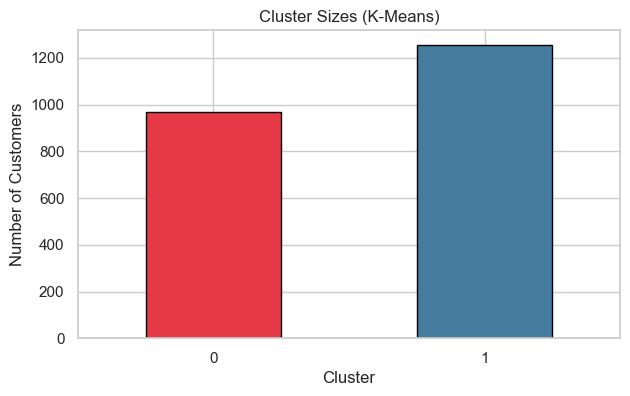

In [8]:
# Cluster size bar chart
plt.figure(figsize=(7, 4))
df_result['Cluster'].value_counts().sort_index().plot(
    kind='bar', color=colors[:K], edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Cluster Sizes (K-Means)')
plt.xticks(rotation=0)
plt.savefig('data/kmeans_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
